In [1]:
 #Mount your personal Google Drive to Colab
from google.colab import drive
drive.mount("/content/drive")
import os
os.chdir("drive")
os.chdir("MyDrive")
os.listdir()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


['Kunskapsskolan',
 'Privat',
 'Celsiusskolan',
 'Universitetet',
 'Kopia av IMG_9843.JPG',
 'Classroom',
 '59571c1a5721453aa412e28fda2fdbd4.mov',
 'Colab Notebooks',
 'SI_for_TA',
 'Examensgasque 2026']

In [2]:
if not os.path.isdir("SI_for_TA"): #create subfolder SI_for_TA does
  os.mkdir("SI_for_TA")
os.chdir("SI_for_TA")
os.getcwd()


'/content/drive/MyDrive/SI_for_TA'

4.1

In [3]:
import numpy as np

values = np.array([1, 2, 3])
counts = np.array([2, 3, 195])
urn = np.repeat(values, counts)

samples = np.random.choice(urn, size=100, replace=True)
print(samples)


[3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3]


4.2

In [4]:
times = np.array([54, 66, 70, 72, 97])

N = 1000
total_times = []

for _ in range(N):
    draw = np.random.choice(times, size=3, replace=True)
    total_times.append(draw.sum())

total_times = np.array(total_times)

prob_over_200 = np.mean(total_times > 200)
prob_over_200


np.float64(0.685)

4.3

Number of plates: 1000
Average number of correct: 89.297
Min/Max: 80 96


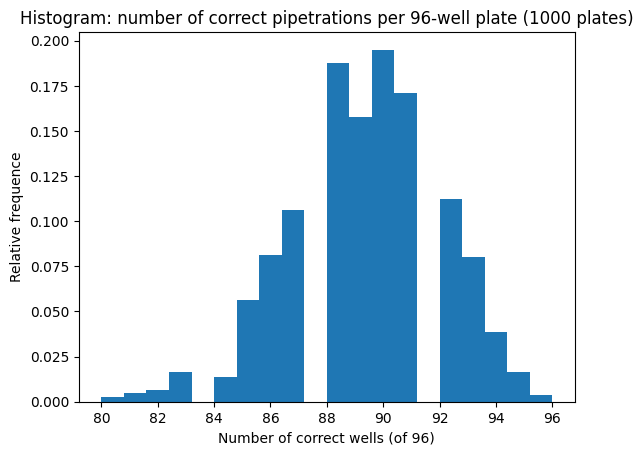

P(number of correct < 80) ≈ 0.0


In [5]:
import numpy as np
import matplotlib.pyplot as plt

urn = np.array([1]*93 + [0]*7)


Nplates = 1000
correct_counts = []

for _ in range(Nplates):
    plate_draw = np.random.choice(urn, size=96, replace=True)
    correct_counts.append(np.sum(plate_draw))

correct_counts = np.array(correct_counts)

print("Number of plates:", len(correct_counts))
print("Average number of correct:", correct_counts.mean())
print("Min/Max:", correct_counts.min(), correct_counts.max())

plt.hist(correct_counts, bins=20, density=True)
plt.xlabel("Number of correct wells (of 96)")
plt.ylabel("Relative frequence")
plt.title("Histogram: number of correct pipetrations per 96-well plate (1000 plates)")
plt.show()

prob_lt_80 = np.mean(correct_counts < 80)
print("P(number of correct < 80) ≈", prob_lt_80)


5.1

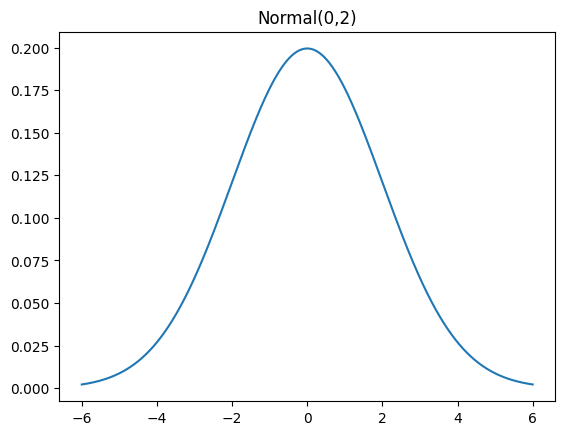

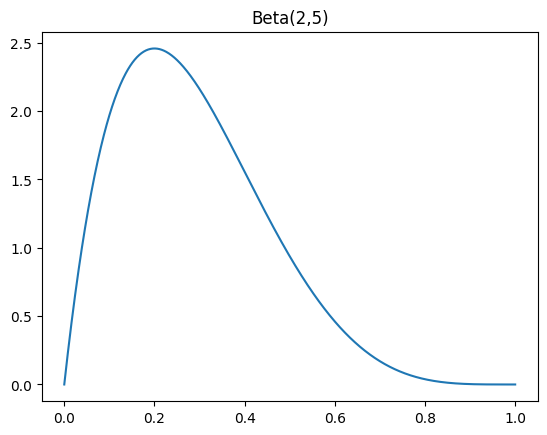

array([0.29502434, 0.20255073, 0.51919809, 0.12130074, 0.20941298,
       0.10963692, 0.46663578, 0.35558307, 0.24065861, 0.15320386])

In [6]:
#a
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, beta

x = np.linspace(-6, 6, 1000)
plt.plot(x, norm.pdf(x, 0, 2))
plt.title("Normal(0,2)")
plt.show()

x2 = np.linspace(0, 1, 1000)
plt.plot(x2, beta.pdf(x2, 2, 5))
plt.title("Beta(2,5)")
plt.show()

#b
np.random.normal(0, 2, 10)
np.random.beta(2, 5, 10)

5.2

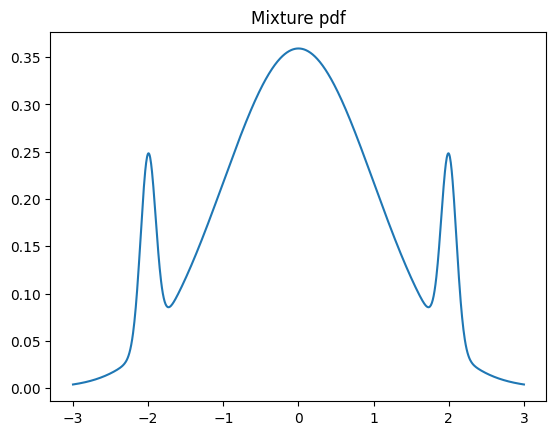

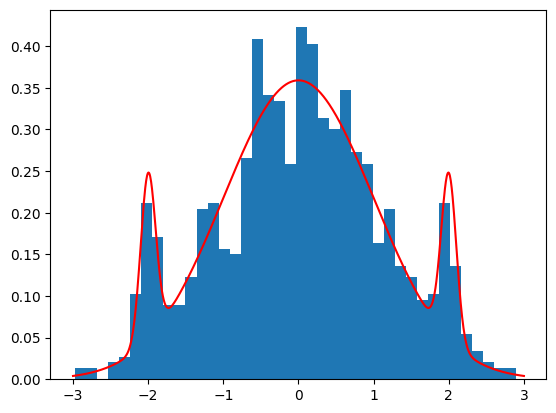

In [7]:
from scipy.stats import norm

x = np.linspace(-3, 3, 1000)

p = (
    0.05 * norm.pdf(x, -2, 0.1)
  + 0.05 * norm.pdf(x,  2, 0.1)
  + 0.90 * norm.pdf(x,  0, 1)
)

plt.plot(x, p)
plt.title("Mixture pdf")
plt.show()

samples = []
for _ in range(1000):
    r = np.random.rand()
    if r < 0.05:
        samples.append(np.random.normal(-2, 0.1))
    elif r < 0.10:
        samples.append(np.random.normal(2, 0.1))
    else:
        samples.append(np.random.normal(0, 1))

plt.hist(samples, bins=40, density=True)
plt.plot(x, p, 'r')
plt.show()


5.3

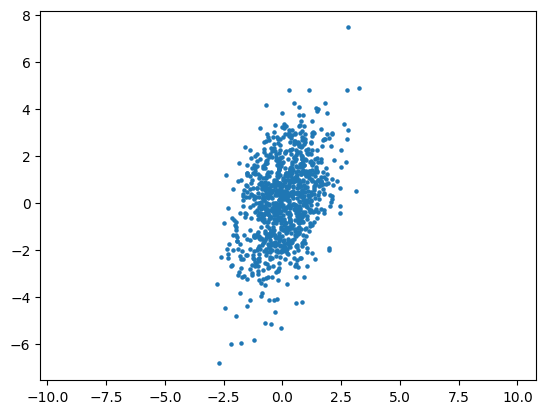

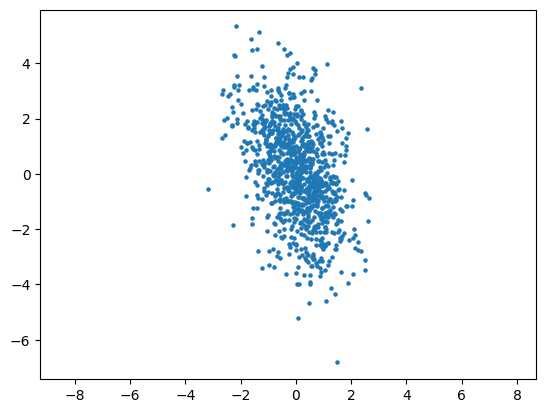

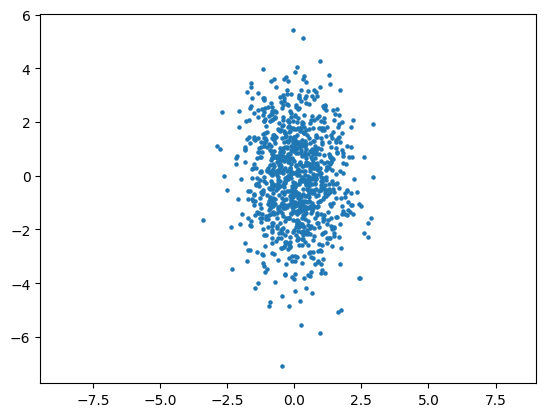

In [8]:
mu = [0, 0]
covs = [
    [[1, 0.7], [0.7, 3]],
    [[1,-0.7],[-0.7,3]],
    [[1, 0], [0, 3]]
]

for cov in covs:
    data = np.random.multivariate_normal(mu, cov, 1000)
    plt.scatter(data[:,0], data[:,1], s=5)
    plt.axis("equal")
    plt.show()


6.1

In [9]:
states = ["G", "M", "A"]
T = {
    "G": [0.8, 0.2, 0.0],
    "M": [0.8, 0.0, 0.2],
    "A": [0.1, 0.0, 0.9]
}

seq = ["G"]
for _ in range(1999):
    seq.append(np.random.choice(states, p=T[seq[-1]]))

last = seq[-1000:]
probs = [last.count(s)/1000 for s in states]
probs


[0.605, 0.122, 0.273]

6.2

In [14]:
states = ["S0","E","5","I","End"]
emissions = ["A","C","G","T"]

T = {
    "S0": [0,1,0,0,0],      # S0 -> E
    "E":  [0,0.9,0.1,0,0],
    "5":  [0,0,0.9,0.1,0],
    "I":  [0,0,0,0.9,0.1]
}

Eprob = {
    "E":[0.3,0.2,0.2,0.3],
    "5":[0.2,0.3,0.3,0.2],
    "I":[0.25,0.25,0.25,0.25]
}

for _ in range(10):

    s = "S0"
    seq = []

    while s != "End":
        s = np.random.choice(states, p=T[s])

        if s in Eprob:
            symbol = np.random.choice(emissions, p=Eprob[s])
            seq.append(symbol)

    print("".join(seq))


AAAGTATTCATTACCAGTTGGTTCAAT
TAGTCTGCCTTGGCCCGGTAGCCAGCGCACCAACA
TTCTGCTGGAATCAGACGAGGGGGTCGGCTCGCGATGCTCAGCA
TCTAAGACGGAAG
CCATGAGGAATGTGCATCGAAGGTGT
ATGCCCTACCGCCACATCTGTAACGACAGC
GCCGAACCTCTCACGAGCTGGAC
TAATGAACAGG
AGTAGGGGATACATCATCCCGACTTATCCGGT
TCAGCCACATG


7.1

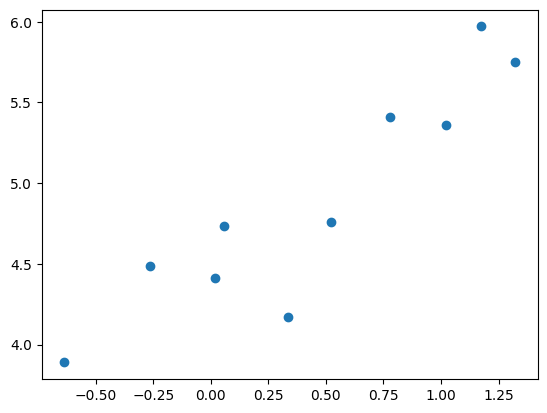

In [13]:
x = np.random.uniform(0,1,10)
y = 2*x + 4

ex = np.random.normal(0,0.3,10)
ey = np.random.normal(0,0.3,10)

x_obs = x + ex
y_obs = y + ey

plt.scatter(x_obs, y_obs)
plt.show()


8
